# Plot single-cell doubling times

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_hex, to_rgb

# from macrohet import plot

# Define the expanded_piyg color map
expanded_piyg = [
    '#1a9641',  # First color from sns.color_palette('PiYG')
    '#a6d96a',  # Second color from sns.color_palette('PiYG')
    '#978897',  # Rose Quartz in hexadecimal format
    '#d1d1ca',  # Timberwolf in RGB normalized form
    '#f1b6da',  # Second-to-last color from sns.color_palette('PiYG')
    '#d02c91'   # Last color from sns.color_palette('PiYG')
]
# Setup
sns.set(style="white", font="Helvetica Neue") #font="Nimbus Sans")
sns.set_palette(['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91'])
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

### Load single-cell data

In [3]:
pickle_path = '/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl'
df = pd.read_pickle(pickle_path)
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


# Final

In [4]:
width_in = 12
height_in = 6
bar_height=0.6

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/3002291024.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


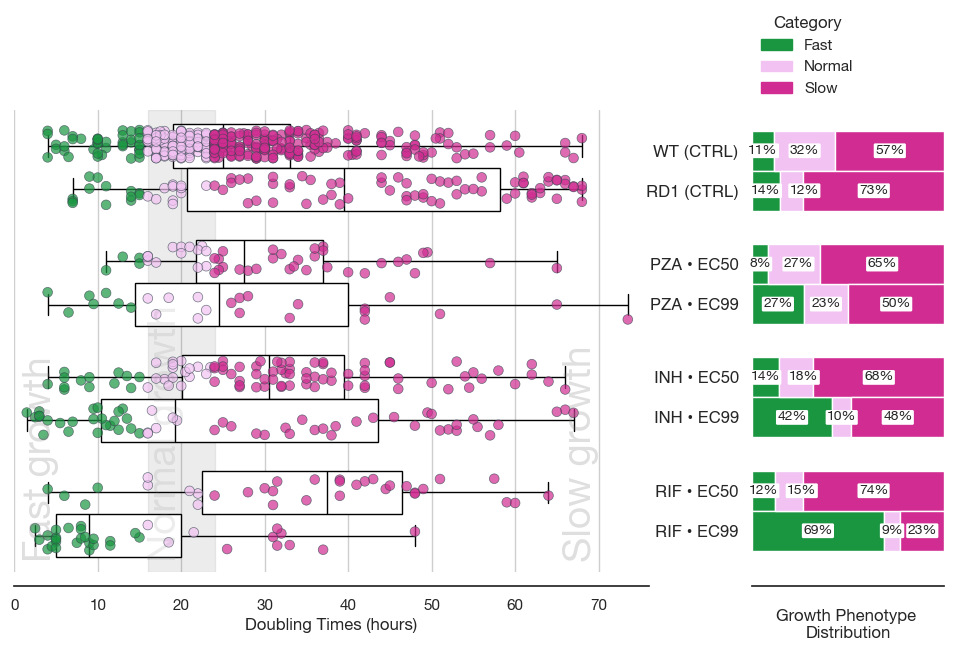

In [48]:
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- Data Cleaning & Preparation ---
df = df[df['mtb_origin']=='Growth'].copy()
# df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])

# Normalize columns
for c in ["Compound", "Strain"]:
    if c in df: df[c] = df[c].astype(str)

# initial clean of concentrations (row count doesn't change here)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[df["Compound"] == "CTRL", "Concentration"] = "EC0"

# Flatten Doubling Times (Row count changes here)
df = df.explode("Doubling Times", ignore_index=True)
df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df = df.dropna(subset=["Doubling Times"])
df = df[(df["Doubling Times"] > 0) & (~np.isinf(df["Doubling Times"]))]

# Deduplicate
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# --- RE-CALCULATE MASK HERE (Post-Explode/Filter) ---
mask_ctrl = df["Compound"] == "CTRL"

# Derived labels & Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")

# Now these assignments work because shapes align
df["Mtb Strain or Drug Compound"] = np.where(mask_ctrl, "CTRL", df["Compound"])
df["CTRL Type"] = np.where(mask_ctrl, df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(mask_ctrl, df["Strain_norm"] + " (CTRL)", df["Compound"])

# --- Configuration ---
strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
conc_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# Colors
fast_c, normal_c, slow_c = expanded_piyg[0], '#F1C2F2', '#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

box_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# --- Helper Function for Plotting ---
def plot_overlay(ax, data, hue_col, hue_order):
    """Draws a base boxplot overlayed with growth-category coloured stripplots."""
    if data.empty: return

    # Base Boxplot
    sns.boxplot(
        data=data, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue=hue_col, order=strain_order, hue_order=hue_order,
        dodge=True, whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
        **box_props
    )
    if ax.legend_: ax.legend_.remove()

    # Stripplots (Loop through Growth Categories to apply specific colours)
    present_hues = [h for h in hue_order if h in data[hue_col].unique()]
    
    for cat in growth_order:
        cat_df = data[data["Growth Category"] == cat]
        if cat_df.empty: continue
        
        # Map every hue level to the single color for this growth category
        palette_map = {lvl: growth_colors[cat] for lvl in present_hues}
        
        sns.stripplot(
            data=cat_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue=hue_col, order=strain_order, hue_order=hue_order,
            dodge=True, palette=palette_map,
            jitter=0.25, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

# --- Figure Layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.25)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# 1. Left Panel: Control Strips
ctrl_df = df[df["Compound"] == "CTRL"]
if not ctrl_df.empty:
    plot_overlay(ax, ctrl_df, "CTRL Type", list(ctrl_df["CTRL Type"].dropna().unique()))

# 2. Left Panel: Drug Strips
drug_df = df[df["Compound"] != "CTRL"]
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if not sub.empty:
        # Filter hue order to only what's present in this subset
        present_concs = [c for c in conc_order if c in sub["Concentration"].unique()]
        plot_overlay(ax, sub, "Concentration", present_concs)

# Background Bands & Labels
xmax = df["Doubling Times"].max() if not df["Doubling Times"].isna().all() else 75
for txt, b0, b1, alpha in [("Fast", bins[0], bins[1], 0.05), ("Normal", bins[1], bins[2], 0.15), ("Slow", bins[2], xmax+3, 0.05)]:
    shaded_region_colour = 'gray' if txt=='Normal' else 'white'       
    ax.axvspan(b0, b1, alpha=alpha, color=shaded_region_colour)

ymax = len(strain_order) - 0.65
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 16, "left", 0.15), ("Slow growth", 70, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    shaded_region_text_colour = '#36454F' if txt=='Normal' else 'gray'   
    ax.text(xpos, ymax, txt, fontsize=28, color=shaded_region_text_colour, alpha=alpha, ha=align, rotation=90)

ax.set(xlabel="Doubling Times (hours)", ylabel="", yticks=[])
ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# --- Right Panel: Stacked Bars ---
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))

valid_rows = [(comp, conc) for comp in right_row_order for conc in conc_order 
              if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if valid_rows:
    g = g.loc[pd.MultiIndex.from_tuples(valid_rows, names=["Display Compound", "Concentration"])]
    props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

    # --- UPDATED POSITION CALCULATION ---
    y_pos = []
    last_group = None  # We track 'group' instead of exact string
    current_y = 0
    group_gap = 0.5
    
    for comp, conc in props.index:
        # LOGIC CHANGE: If it contains "(CTRL)", treat it as the same group
        current_group = "CTRL_GROUP" if "(CTRL)" in comp else comp
        
        if last_group is not None:
            if current_group == last_group:
                # Same group -> Touch (increment by height only)
                current_y += bar_height
            else:
                # Different group -> Gap
                current_y += (bar_height + group_gap)
        
        y_pos.append(current_y)
        last_group = current_group
        
    y_pos = np.array(y_pos)
    # ------------------------------------

    lefts = np.zeros(len(props))
    fast_label_x = {}
    min_separation = 0.2

    for gr in growth_order:
        if gr not in props.columns: continue
        vals = props[gr].values
        
        # Plot bars using custom y_pos
        bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, 
                           label=gr, color=growth_colors[gr], edgecolor="white")
        
        # Labels with overlap protection
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 0.05: 
                x_center = bar.get_x() + bar.get_width() / 2
                y_center = bar.get_y() + bar.get_height() / 2
                
                if gr == "Fast":
                    fast_label_x[i] = x_center
                elif gr == "Normal":
                    if i in fast_label_x:
                        dist = x_center - fast_label_x[i]
                        if dist < min_separation:
                            x_center = fast_label_x[i] + min_separation

                ax_bar.text(x_center, y_center, 
                            f"{v*100:.0f}%", 
                            ha="center", va="center", fontsize=10, fontweight="bold",
                            bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))
                            
        lefts += vals

    ax_bar.set(xlim=(0, 1), xticks=[], yticks=y_pos, ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
    
    # Label formatting
    labels = [f"{c} • {conc}" if conc != 'EC0' else c for c, conc in props.index]
    ax_bar.set_yticklabels(labels)
    plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')
    
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]
    ax_bar.legend(handles=handles, title="Category", loc="lower right", frameon=False, bbox_to_anchor=(0.6, 1.0))
else:
    ax_bar.axis("off")

ax.set_xlim(0, 76)
plt.tight_layout()
plt.show()

### Displaced percentage labels

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/458003742.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


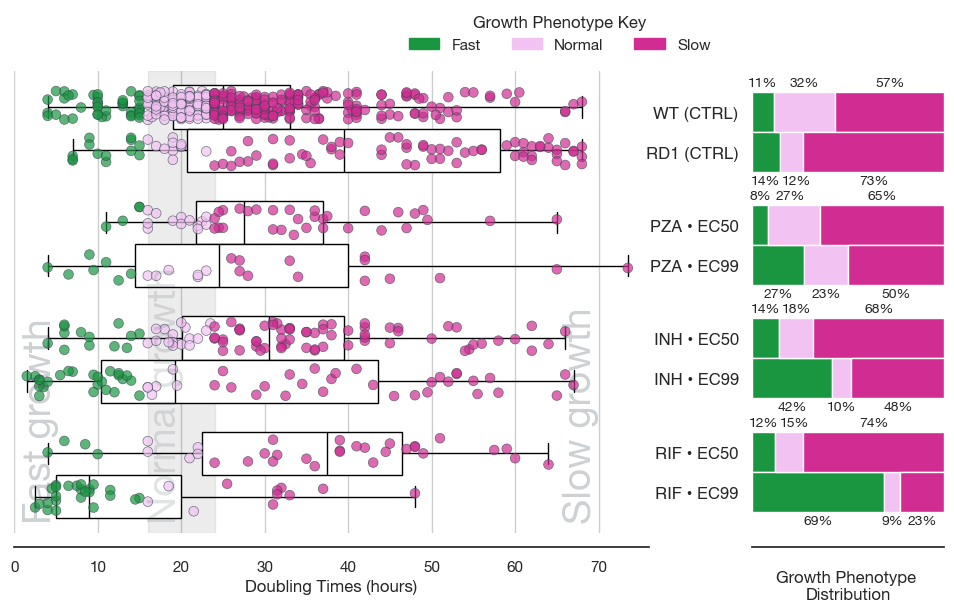

In [89]:
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- Data Cleaning & Preparation ---
df = df[df['mtb_origin']=='Growth'].copy()
# df["Mtb Strain or Drug Compound"] = np.where(df["Compound"].eq("CTRL"), "CTRL", df["Compound"])

# Normalize columns
for c in ["Compound", "Strain"]:
    if c in df: df[c] = df[c].astype(str)

# initial clean of concentrations (row count doesn't change here)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[df["Compound"] == "CTRL", "Concentration"] = "EC0"

# Flatten Doubling Times (Row count changes here)
df = df.explode("Doubling Times", ignore_index=True)
df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df = df.dropna(subset=["Doubling Times"])
df = df[(df["Doubling Times"] > 0) & (~np.isinf(df["Doubling Times"]))]

# Deduplicate
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# --- RE-CALCULATE MASK HERE (Post-Explode/Filter) ---
mask_ctrl = df["Compound"] == "CTRL"

# Derived labels & Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")

# Now these assignments work because shapes align
df["Mtb Strain or Drug Compound"] = np.where(mask_ctrl, "CTRL", df["Compound"])
df["CTRL Type"] = np.where(mask_ctrl, df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(mask_ctrl, df["Strain_norm"] + " (CTRL)", df["Compound"])

# --- Configuration ---
strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
conc_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# Colors
fast_c, normal_c, slow_c = expanded_piyg[0], '#F1C2F2', '#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

box_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# --- Helper Function for Plotting ---
def plot_overlay(ax, data, hue_col, hue_order):
    """Draws a base boxplot overlayed with growth-category coloured stripplots."""
    if data.empty: return

    # Base Boxplot
    sns.boxplot(
        data=data, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue=hue_col, order=strain_order, hue_order=hue_order,
        dodge=True, whis=[0, 100], width=0.75, linewidth=1.0, fliersize=0, ax=ax,
        **box_props
    )
    if ax.legend_: ax.legend_.remove()

    # Stripplots (Loop through Growth Categories to apply specific colours)
    present_hues = [h for h in hue_order if h in data[hue_col].unique()]
    
    for cat in growth_order:
        cat_df = data[data["Growth Category"] == cat]
        if cat_df.empty: continue
        
        # Map every hue level to the single color for this growth category
        palette_map = {lvl: growth_colors[cat] for lvl in present_hues}
        
        sns.stripplot(
            data=cat_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue=hue_col, order=strain_order, hue_order=hue_order,
            dodge=True, palette=palette_map,
            jitter=0.25, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

# --- Figure Layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.25)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# 1. Left Panel: Control Strips
ctrl_df = df[df["Compound"] == "CTRL"]
if not ctrl_df.empty:
    plot_overlay(ax, ctrl_df, "CTRL Type", list(ctrl_df["CTRL Type"].dropna().unique()))

# 2. Left Panel: Drug Strips
drug_df = df[df["Compound"] != "CTRL"]
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if not sub.empty:
        # Filter hue order to only what's present in this subset
        present_concs = [c for c in conc_order if c in sub["Concentration"].unique()]
        plot_overlay(ax, sub, "Concentration", present_concs)

# Background Bands & Labels
xmax = df["Doubling Times"].max() if not df["Doubling Times"].isna().all() else 75
for txt, b0, b1, alpha in [("Fast", bins[0], bins[1], 0.05), ("Normal", bins[1], bins[2], 0.15), ("Slow", bins[2], xmax+3, 0.05)]:
    shaded_region_colour = 'gray' if txt=='Normal' else 'white'       
    ax.axvspan(b0, b1, alpha=alpha, color=shaded_region_colour)

ymax = len(strain_order) - 0.65
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 16, "left", 0.15), ("Slow growth", 70, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    ax.text(xpos, ymax, txt, fontsize=28, color='#36454F', alpha=alpha, ha=align, rotation=90)

ax.set(xlabel="Doubling Times (hours)", ylabel="", yticks=[])
ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# --- Right Panel: Stacked Bars ---
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))

valid_rows = [(comp, conc) for comp in right_row_order for conc in conc_order 
              if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if valid_rows:
    g = g.loc[pd.MultiIndex.from_tuples(valid_rows, names=["Display Compound", "Concentration"])]
    props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

    # --- UPDATED POSITION CALCULATION ---
    y_pos = []
    last_group = None  # We track 'group' instead of exact string
    current_y = 0
    group_gap = 0.5
    
    for comp, conc in props.index:
        # LOGIC CHANGE: If it contains "(CTRL)", treat it as the same group
        current_group = "CTRL_GROUP" if "(CTRL)" in comp else comp
        
        if last_group is not None:
            if current_group == last_group:
                # Same group -> Touch (increment by height only)
                current_y += bar_height
            else:
                # Different group -> Gap
                current_y += (bar_height + group_gap)
        
        y_pos.append(current_y)
        last_group = current_group
        
    y_pos = np.array(y_pos)
    # ------------------------------------

    lefts = np.zeros(len(props))
    fast_label_x = {}
    min_separation = 0.2

    for gr in growth_order:
        if gr not in props.columns: continue
        vals = props[gr].values
        
        # Plot bars using custom y_pos
        bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, 
                           label=gr, color=growth_colors[gr], edgecolor="white")
        
        shift_amount = 0.43 

        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 0.05: 
                x_center = bar.get_x() + bar.get_width() / 2
                base_y = bar.get_y() + bar.get_height() / 2
                
                # --- ALTERNATING LOGIC ---
                # Even index (0, 2...) -> Shift UP (-)
                # Odd index (1, 3...)  -> Shift DOWN (+)
                if i % 2 == 0:
                    y_center = base_y - shift_amount - 0.005
                else:
                    y_center = base_y + shift_amount + 0.005
                # -------------------------
    
                if gr == "Fast":
                    fast_label_x[i] = x_center
                elif gr == "Normal":
                    if i in fast_label_x:
                        dist = x_center - fast_label_x[i]
                        if dist < min_separation:
                            x_center = fast_label_x[i] + min_separation -0.04
    
                ax_bar.text(x_center, y_center, 
                            f"{v*100:.0f}%", 
                            ha="center", va="center", fontsize=10, fontweight="bold",
                            bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))                    
        lefts += vals

    ax_bar.set(xlim=(0, 1), xticks=[], yticks=y_pos, ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
    
    # Label formatting
    labels = [f"{c} • {conc}" if conc != 'EC0' else c for c, conc in props.index]
    ax_bar.set_yticklabels(labels)
    plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')
    
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]
    ax_bar.legend(handles=handles, title="Growth Phenotype Key", loc="upper center", frameon=False, bbox_to_anchor=(-1, 1.15), ncol=3)
else:
    ax_bar.axis("off")

ax.set_xlim(0, 76)
plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/doubling_times_phenotype_colour_code_shifted_percentages.pdf', bbox_inches='tight', dpi=314)
plt.show()

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/3262987292.py:70: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/3262987292.py:70: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/3262987292.py:70: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/3262987292.py:70: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T

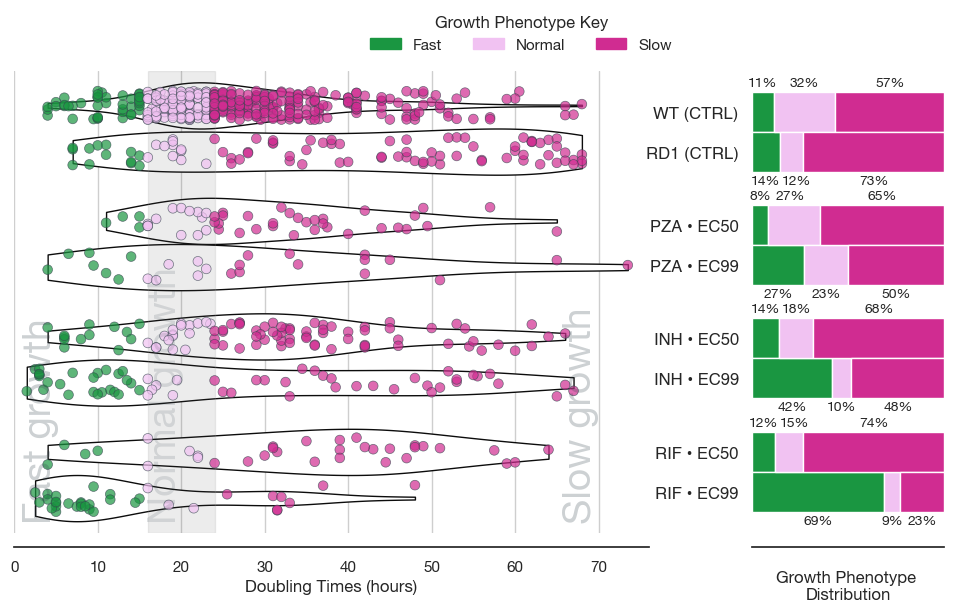

In [90]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- Contextual Definitions (Restored from memory) ---
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

# --- Data Cleaning & Preparation ---
df = df[df['mtb_origin']=='Growth'].copy()

# Normalize columns
for c in ["Compound", "Strain"]:
    if c in df: df[c] = df[c].astype(str)

# initial clean of concentrations (row count doesn't change here)
df["Concentration"] = df.get("Concentration", "EC0").fillna("EC0").astype(str)
df.loc[df["Compound"] == "CTRL", "Concentration"] = "EC0"

# Flatten Doubling Times (Row count changes here)
df = df.explode("Doubling Times", ignore_index=True)
df["Doubling Times"] = pd.to_numeric(df["Doubling Times"], errors="coerce")
df = df.dropna(subset=["Doubling Times"])
df = df[(df["Doubling Times"] > 0) & (~np.isinf(df["Doubling Times"]))]

# Deduplicate
keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in df.columns]
df = df.drop_duplicates(subset=keys).copy()

# --- RE-CALCULATE MASK HERE (Post-Explode/Filter) ---
mask_ctrl = df["Compound"] == "CTRL"

# Derived labels & Binning
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
df["Growth Category"] = pd.cut(df["Doubling Times"], bins=bins, labels=labels, right=False)

rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")

# Now these assignments work because shapes align
df["Mtb Strain or Drug Compound"] = np.where(mask_ctrl, "CTRL", df["Compound"])
df["CTRL Type"] = np.where(mask_ctrl, df["Strain_norm"], pd.NA)
df["Display Compound"] = np.where(mask_ctrl, df["Strain_norm"] + " (CTRL)", df["Compound"])

# --- Configuration ---
strain_order = ["CTRL", "PZA", "INH", "RIF"]
right_row_order = ["WT (CTRL)", "RD1 (CTRL)", "PZA", "INH", "RIF"]
conc_order = ["EC50", "EC0", "EC99"]
growth_order = ["Fast", "Normal", "Slow"]

# Colors
fast_c, normal_c, slow_c = expanded_piyg[0], '#F1C2F2', '#D02C91'
growth_colors = {"Fast": fast_c, "Normal": normal_c, "Slow": slow_c}

# --- Helper Function for Plotting (Modified for Violin) ---
def plot_overlay(ax, data, hue_col, hue_order):
    """Draws a base violinplot overlayed with growth-category coloured stripplots."""
    if data.empty: return

    # Base Violinplot
    # We force the palette to white to mimic the clean 'box' style
    white_palette = {h: "white" for h in hue_order}
    
    sns.violinplot(
        data=data, x="Doubling Times", y="Mtb Strain or Drug Compound",
        hue=hue_col, order=strain_order, hue_order=hue_order,
        dodge=True, 
        inner=None,      # Clean interior (no quartiles inside)
        cut=0,           # Limit KDE to data range (no extrapolation)
        scale='width',   # Normalize width for visibility
        linewidth=1.0, 
        linecolor='black',
        palette=white_palette,
        saturation=1,    # Avoid dimming the white
        ax=ax
    )
    if ax.legend_: ax.legend_.remove()

    # Stripplots (Loop through Growth Categories to apply specific colours)
    present_hues = [h for h in hue_order if h in data[hue_col].unique()]
    
    for cat in growth_order:
        cat_df = data[data["Growth Category"] == cat]
        if cat_df.empty: continue
        
        # Map every hue level to the single color for this growth category
        palette_map = {lvl: growth_colors[cat] for lvl in present_hues}
        
        sns.stripplot(
            data=cat_df, x="Doubling Times", y="Mtb Strain or Drug Compound",
            hue=hue_col, order=strain_order, hue_order=hue_order,
            dodge=True, palette=palette_map,
            jitter=0.25, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax
        )
        if ax.legend_: ax.legend_.remove()

# --- Figure Layout ---
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.3, 1], wspace=0.25)
ax = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# 1. Left Panel: Control Strips
ctrl_df = df[df["Compound"] == "CTRL"]
if not ctrl_df.empty:
    plot_overlay(ax, ctrl_df, "CTRL Type", list(ctrl_df["CTRL Type"].dropna().unique()))

# 2. Left Panel: Drug Strips
drug_df = df[df["Compound"] != "CTRL"]
for compound in ["PZA", "INH", "RIF"]:
    sub = drug_df[drug_df["Mtb Strain or Drug Compound"] == compound]
    if not sub.empty:
        # Filter hue order to only what's present in this subset
        present_concs = [c for c in conc_order if c in sub["Concentration"].unique()]
        plot_overlay(ax, sub, "Concentration", present_concs)

# Background Bands & Labels
xmax = df["Doubling Times"].max() if not df["Doubling Times"].isna().all() else 75
for txt, b0, b1, alpha in [("Fast", bins[0], bins[1], 0.05), ("Normal", bins[1], bins[2], 0.15), ("Slow", bins[2], xmax+3, 0.05)]:
    shaded_region_colour = 'gray' if txt=='Normal' else 'white'        
    ax.axvspan(b0, b1, alpha=alpha, color=shaded_region_colour)

ymax = len(strain_order) - 0.65
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 16, "left", 0.15), ("Slow growth", 70, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    ax.text(xpos, ymax, txt, fontsize=28, color='#36454F', alpha=alpha, ha=align, rotation=90)

ax.set(xlabel="Doubling Times (hours)", ylabel="", yticks=[])
ax.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax)

# --- Right Panel: Stacked Bars ---
g = (df.groupby(["Display Compound", "Concentration", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))

valid_rows = [(comp, conc) for comp in right_row_order for conc in conc_order 
              if (comp, conc) in g.index and g.loc[(comp, conc)].sum() > 0]

if valid_rows:
    g = g.loc[pd.MultiIndex.from_tuples(valid_rows, names=["Display Compound", "Concentration"])]
    props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

    # --- UPDATED POSITION CALCULATION ---
    y_pos = []
    last_group = None 
    current_y = 0
    group_gap = 0.5
    
    for comp, conc in props.index:
        current_group = "CTRL_GROUP" if "(CTRL)" in comp else comp
        
        if last_group is not None:
            if current_group == last_group:
                current_y += bar_height
            else:
                current_y += (bar_height + group_gap)
        
        y_pos.append(current_y)
        last_group = current_group
        
    y_pos = np.array(y_pos)
    # ------------------------------------

    lefts = np.zeros(len(props))
    fast_label_x = {}
    min_separation = 0.2

    for gr in growth_order:
        if gr not in props.columns: continue
        vals = props[gr].values
        
        # Plot bars
        bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, 
                           label=gr, color=growth_colors[gr], edgecolor="white")
        
        shift_amount = 0.43 

        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 0.05: 
                x_center = bar.get_x() + bar.get_width() / 2
                base_y = bar.get_y() + bar.get_height() / 2
                
                # --- ALTERNATING LOGIC ---
                if i % 2 == 0:
                    y_center = base_y - shift_amount - 0.005
                else:
                    y_center = base_y + shift_amount + 0.005
                # -------------------------
    
                if gr == "Fast":
                    fast_label_x[i] = x_center
                elif gr == "Normal":
                    if i in fast_label_x:
                        dist = x_center - fast_label_x[i]
                        if dist < min_separation:
                            x_center = fast_label_x[i] + min_separation -0.04
    
                ax_bar.text(x_center, y_center, 
                            f"{v*100:.0f}%", 
                            ha="center", va="center", fontsize=10, fontweight="bold",
                            bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))                    
        lefts += vals

    ax_bar.set(xlim=(0, 1), xticks=[], yticks=y_pos, ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
    
    # Label formatting
    labels = [f"{c} • {conc}" if conc != 'EC0' else c for c, conc in props.index]
    ax_bar.set_yticklabels(labels)
    plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')
    
    ax_bar.invert_yaxis()
    sns.despine(offset=10, left=True, ax=ax_bar)

    handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]
    ax_bar.legend(handles=handles, title="Growth Phenotype Key", loc="upper center", frameon=False, bbox_to_anchor=(-1.2, 1.15), ncol=3)
else:
    ax_bar.axis("off")

ax.set_xlim(0, 76)
plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/doubling_times_violin_plot_phenotype_colour_code_shifted_percentages.pdf', bbox_inches='tight', dpi=314)
plt.show()

# Temp comparative plotting

In [91]:
df_3d = pd.read_pickle('/Volumes/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/3.3.max_proj_sc_df.update.pkl')

In [92]:
df_3d

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times,mtb_origin
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.000000,1.000000,"[1.92, 3.84, 7.68, 15.36]","[1.0, 0.5, 8.0]",Transfer
1,0,6,24,525.0,4880.0,17250.0,0.0,755.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.000000,0.804189,NaN,NaN,None
2,0,9,22,7490.0,1929.0,18000.0,0.0,64.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.144179,0.247361,NaN,NaN,None
3,0,10,22,4221.0,542.0,47050.0,101.0,1009.0,3.0,3.0,2.257073,0.0,2.257073,0.0,2.266954,0.916470,NaN,NaN,None
4,0,11,24,4548.0,823.0,23025.0,123.0,442.0,3.0,3.0,2.748713,0.0,2.748713,0.0,2.484378,0.810000,"[2.363652037311596, 4.727304074623192, 9.45460...","[5.0, 16.0, -1.0, -5.5]",Transfer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130363,96,8595,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,11.374755,48.0,11.374755,0.646219,NaN,NaN,None
130364,96,8597,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,3.195658,48.0,3.201369,0.584448,NaN,NaN,None
130365,96,8600,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.938153,"[1.92, 3.84, 7.68]","[-2.5, -16.0]",None
130366,96,8617,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.850124,"[1.92, 3.84]",[-5.5],None


/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/920828214.py:53: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/920828214.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


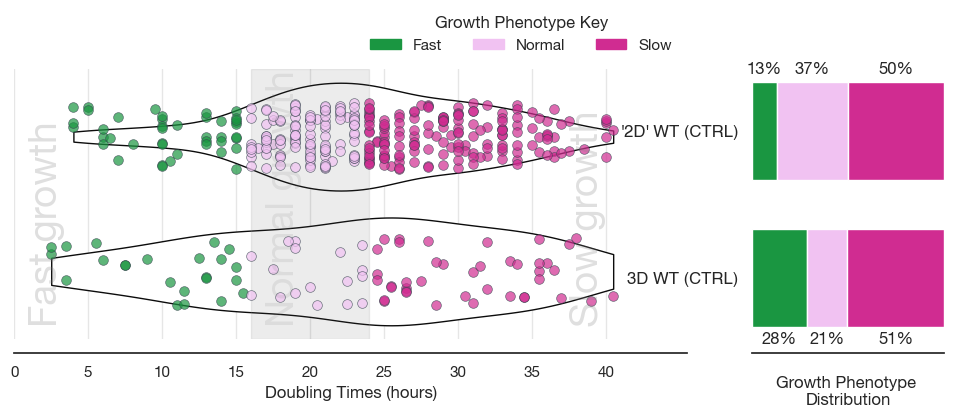

In [138]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# --- 1. Prepare 2D Reference Data ---
df_2d_ref = df[(df["Strain_norm"] == "WT") & (df["Compound"] == "CTRL")].copy()
df_2d_ref["Experiment"] = "'2D' WT (CTRL)"

# --- 2. Prepare 3D Data ---
df_3d_clean = df_3d[df_3d['mtb_origin']=='Growth'].copy()

if "Doubling Times" in df_3d_clean.columns:
    df_3d_clean = df_3d_clean.drop_duplicates("ID")
    df_3d_clean = df_3d_clean.explode("Doubling Times", ignore_index=True)
    df_3d_clean["Doubling Times"] = pd.to_numeric(df_3d_clean["Doubling Times"], errors="coerce")
    df_3d_clean = df_3d_clean.dropna(subset=["Doubling Times"])
    df_3d_clean = df_3d_clean[(df_3d_clean["Doubling Times"] > 0) & (~np.isinf(df_3d_clean["Doubling Times"]))]
    df_3d_clean["Experiment"] = "3D WT (CTRL)"
else:
    raise ValueError("df_3d must contain a 'Doubling Times' column")

# Limit 2D data to the max of 3D data for cleaner plotting
df_2d_ref = df_2d_ref[df_2d_ref["Doubling Times"] <= df_3d_clean["Doubling Times"].max()]

# --- 3. Combine & Bin ---
comp_df = pd.concat([df_2d_ref, df_3d_clean], ignore_index=True)

bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
comp_df["Growth Category"] = pd.cut(comp_df["Doubling Times"], bins=bins, labels=labels, right=False)

# --- 4. Plotting Configuration ---
width_in, height_in = 12, 3.5
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.15) 

ax_violin = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

y_order = ["'2D' WT (CTRL)", "3D WT (CTRL)"]
growth_order = ["Fast", "Normal", "Slow"]
growth_colors = {"Fast": '#1a9641', "Normal": '#F1C2F2', "Slow": '#D02C91'}

# ===========================
# LEFT PANEL: VIOLIN & STRIP
# ===========================

# A. Base Violin Plot
sns.violinplot(
    data=comp_df, x="Doubling Times", y="Experiment",
    order=y_order, inner=None, cut=0, scale='width', 
    linewidth=1.0, linecolor="black", color="white", saturation=1, ax=ax_violin
)

# B. Colored Strip Plots
for cat in growth_order:
    cat_data = comp_df[comp_df["Growth Category"] == cat]
    if cat_data.empty: continue
    
    sns.stripplot(
        data=cat_data, x="Doubling Times", y="Experiment",
        order=y_order,
        color=growth_colors[cat],
        jitter=0.25, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax_violin
    )

# Background Shading
xmax = comp_df["Doubling Times"].max()
for txt, b0, b1, alpha in [("Fast", 0, 16, 0.05), ("Normal", 16, 24, 0.15), ("Slow", 24, xmax+5, 0.05)]:
    color = 'gray' if txt=='Normal' else 'white'        
    ax_violin.axvspan(b0, b1, alpha=alpha, color=color)

# --- NEW LABEL LOGIC (Matches Original Style) ---
# Calculate Y-max based on number of rows (0-indexed categorical plot)
ymax = len(y_order) - 0.65 

labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 17, "left", 0.15), ("Slow growth", 40, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    shaded_region_text_colour = '#36454F' if txt=='Normal' else 'gray'    
    ax_violin.text(xpos, ymax, txt, fontsize=28, color=shaded_region_text_colour, alpha=alpha, ha=align, rotation=90)
# -----------------------------------------------

ax_violin.set(xlabel="Doubling Times (hours)", ylabel="", xlim=(0, xmax+5))

# 2. Create ticks every 5, but explicitly exclude 45
ticks = np.arange(0, xmax + 10, 5) # Generate range
ticks = [t for t in ticks if t != 45] # Remove 45

# 3. Apply the custom ticks
ax_violin.xaxis.set_major_locator(ticker.FixedLocator(ticks))
ax_violin.grid(True, axis='x', linestyle='-', alpha=0.5)

ax_violin.set_yticks([]) 
sns.despine(offset=10, left=True, ax=ax_violin)


# ===========================
# RIGHT PANEL: STACKED BARS
# ===========================

# Group Data
g = (comp_df.groupby(["Experiment", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))
g = g.reindex(y_order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

spacing = 0.3      # Distance between row centers
thickness = 0.2     # Actual thickness of the bar (must be < spacing for gaps)

y_pos = np.arange(len(y_order)) * spacing

lefts = np.zeros(len(props))
fast_label_x = {}
min_separation = 0.1

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=thickness, 
                       label=gr, color=growth_colors[gr], edgecolor="white")
    
    shift_amount = 0.12
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_center = bar.get_x() + bar.get_width() / 2
            base_y = bar.get_y() + bar.get_height() / 2
            
            if i % 2 == 0:
                y_center = base_y - shift_amount - 0.005
            else:
                y_center = base_y + shift_amount + 0.005

            if gr == "Fast":
                fast_label_x[i] = x_center
            elif gr == "Normal":
                if i in fast_label_x:
                    dist = x_center - fast_label_x[i]
                    if dist < min_separation:
                        x_center = fast_label_x[i] + min_separation - 0.05

            ax_bar.text(x_center, y_center, 
                        f"{v*100:.0f}%", 
                        ha="center", va="center", fontsize=12, fontweight="bold",
                        bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))  
    ax_bar.legend(handles=handles, title="Growth Phenotype Key", loc="upper center", frameon=False, bbox_to_anchor=(-1.2, 1.25), ncol=3)

    lefts += vals

ax_bar.set(xlim=(0, 1), xticks=[], ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(props.index)
plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')

ax_bar.invert_yaxis()
sns.despine(offset=10, left=True, ax=ax_bar)

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/3D_doubling_times_violin_plot_phenotype_colour_code_shifted_percentages.pdf', bbox_inches='tight', dpi=314)
plt.show()

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/3259096948.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


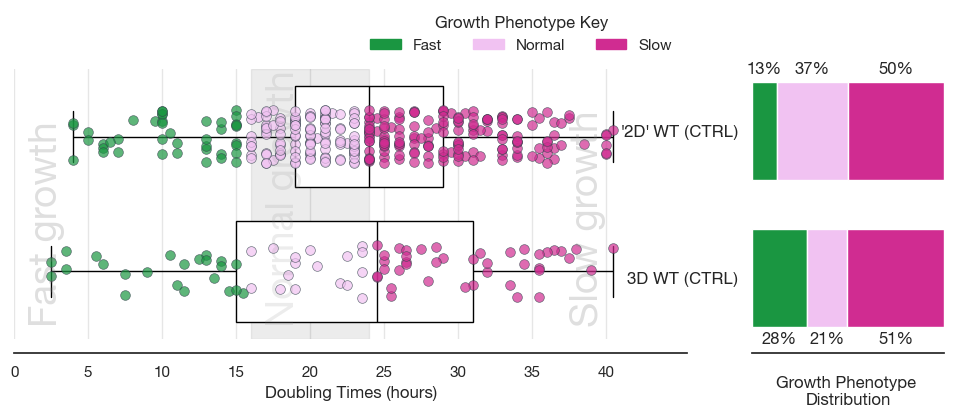

In [148]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- 1. Prepare 2D Reference Data ---
df_2d_ref = df[(df["Strain_norm"] == "WT") & (df["Compound"] == "CTRL")].copy()
df_2d_ref["Experiment"] = "'2D' WT (CTRL)"

# --- 2. Prepare 3D Data ---
df_3d_clean = df_3d[df_3d['mtb_origin']=='Growth'].copy()

if "Doubling Times" in df_3d_clean.columns:
    df_3d_clean = df_3d_clean.drop_duplicates("ID")
    df_3d_clean = df_3d_clean.explode("Doubling Times", ignore_index=True)
    df_3d_clean["Doubling Times"] = pd.to_numeric(df_3d_clean["Doubling Times"], errors="coerce")
    df_3d_clean = df_3d_clean.dropna(subset=["Doubling Times"])
    df_3d_clean = df_3d_clean[(df_3d_clean["Doubling Times"] > 0) & (~np.isinf(df_3d_clean["Doubling Times"]))]
    df_3d_clean["Experiment"] = "3D WT (CTRL)"
else:
    raise ValueError("df_3d must contain a 'Doubling Times' column")

# Limit 2D data to the max of 3D data for cleaner plotting
df_2d_ref = df_2d_ref[df_2d_ref["Doubling Times"] <= df_3d_clean["Doubling Times"].max()]

# --- 3. Combine & Bin ---
comp_df = pd.concat([df_2d_ref, df_3d_clean], ignore_index=True)

bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
comp_df["Growth Category"] = pd.cut(comp_df["Doubling Times"], bins=bins, labels=labels, right=False)

# --- 4. Plotting Configuration ---
width_in, height_in = 12, 3.5
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.15) 

ax_box = plt.subplot(gs[0]) # Renamed for clarity, though ax_violin would work
ax_bar = plt.subplot(gs[1])

y_order = ["'2D' WT (CTRL)", "3D WT (CTRL)"]
growth_order = ["Fast", "Normal", "Slow"]
growth_colors = {"Fast": '#1a9641', "Normal": '#F1C2F2', "Slow": '#D02C91'}

# ===========================
# LEFT PANEL: BOX & STRIP
# ===========================

box_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# A. Base Box Plot
sns.boxplot(
    data=comp_df, x="Doubling Times", y="Experiment",
    order=y_order, 
    width=0.75,           # Adjust width to match the bar thickness roughly
    linewidth=1.0, 
    fliersize=0,         # Hide outliers (handled by stripplot)
    ax=ax_box,
    **box_props
)

# B. Colored Strip Plots
for cat in growth_order:
    cat_data = comp_df[comp_df["Growth Category"] == cat]
    if cat_data.empty: continue
    
    sns.stripplot(
        data=cat_data, x="Doubling Times", y="Experiment",
        order=y_order,
        color=growth_colors[cat],
        jitter=0.2, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax_box
    )

# Background Shading
xmax = comp_df["Doubling Times"].max()
for txt, b0, b1, alpha in [("Fast", 0, 16, 0.05), ("Normal", 16, 24, 0.15), ("Slow", 24, xmax+5, 0.05)]:
    color = 'gray' if txt=='Normal' else 'white'        
    ax_box.axvspan(b0, b1, alpha=alpha, color=color)

# --- LABEL LOGIC ---
ymax = len(y_order) - 0.65 
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 17, "left", 0.15), ("Slow growth", 40, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    shaded_region_text_colour = '#36454F' if txt=='Normal' else 'gray'    
    ax_box.text(xpos, ymax, txt, fontsize=28, color=shaded_region_text_colour, alpha=alpha, ha=align, rotation=90)
# -------------------

ax_box.set(xlabel="Doubling Times (hours)", ylabel="", xlim=(0, xmax+5))

# Ticks every 5, excluding 45
ticks = np.arange(0, xmax + 10, 5) 
ticks = [t for t in ticks if t != 45] 

ax_box.xaxis.set_major_locator(ticker.FixedLocator(ticks))
ax_box.grid(True, axis='x', linestyle='-', alpha=0.5)

ax_box.set_yticks([]) 
sns.despine(offset=10, left=True, ax=ax_box)


# ===========================
# RIGHT PANEL: STACKED BARS
# ===========================

# Group Data
g = (comp_df.groupby(["Experiment", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))
g = g.reindex(y_order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

spacing = 0.3      
thickness = 0.2     

y_pos = np.arange(len(y_order)) * spacing

lefts = np.zeros(len(props))
fast_label_x = {}
min_separation = 0.1
handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=thickness, 
                       label=gr, color=growth_colors[gr], edgecolor="white")
    
    shift_amount = 0.12
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_center = bar.get_x() + bar.get_width() / 2
            base_y = bar.get_y() + bar.get_height() / 2
            
            if i % 2 == 0:
                y_center = base_y - shift_amount - 0.005
            else:
                y_center = base_y + shift_amount + 0.005

            if gr == "Fast":
                fast_label_x[i] = x_center
            elif gr == "Normal":
                if i in fast_label_x:
                    dist = x_center - fast_label_x[i]
                    if dist < min_separation:
                        x_center = fast_label_x[i] + min_separation - 0.05

            ax_bar.text(x_center, y_center, 
                        f"{v*100:.0f}%", 
                        ha="center", va="center", fontsize=12, fontweight="bold",
                        bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))  

    lefts += vals

ax_bar.legend(handles=handles, title="Growth Phenotype Key", loc="upper center", frameon=False, bbox_to_anchor=(-1.2, 1.25), ncol=3)

ax_bar.set(xlim=(0, 1), xticks=[], ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(props.index)
plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')

ax_bar.invert_yaxis()
sns.despine(offset=10, left=True, ax=ax_bar)

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/3D_doubling_times_box_plot_phenotype_colour_code_shifted_percentages.pdf', bbox_inches='tight', dpi=314)
plt.show()

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/2105896450.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


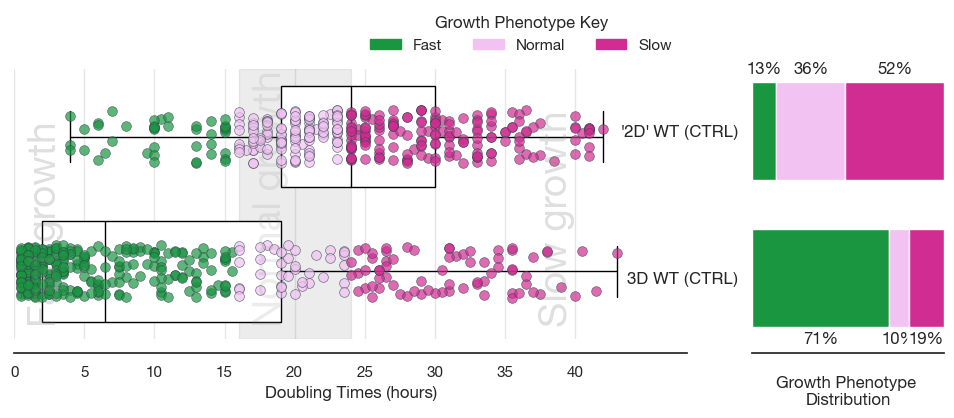

In [147]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- 1. Prepare 2D Reference Data ---
df_2d_ref = df[(df["Strain_norm"] == "WT") & (df["Compound"] == "CTRL")].copy()
df_2d_ref["Experiment"] = "'2D' WT (CTRL)"

# --- 2. Prepare 3D Data ---
df_3d_clean = df_3d.copy()#[df_3d['mtb_origin']=='Growth'].copy()

if "Doubling Times" in df_3d_clean.columns:
    df_3d_clean = df_3d_clean.drop_duplicates("ID")
    df_3d_clean = df_3d_clean.explode("Doubling Times", ignore_index=True)
    df_3d_clean["Doubling Times"] = pd.to_numeric(df_3d_clean["Doubling Times"], errors="coerce")
    df_3d_clean = df_3d_clean.dropna(subset=["Doubling Times"])
    df_3d_clean = df_3d_clean[(df_3d_clean["Doubling Times"] > 0) & (~np.isinf(df_3d_clean["Doubling Times"]))]
    df_3d_clean["Experiment"] = "3D WT (CTRL)"
else:
    raise ValueError("df_3d must contain a 'Doubling Times' column")

# Limit 2D data to the max of 3D data for cleaner plotting
df_2d_ref = df_2d_ref[df_2d_ref["Doubling Times"] <= df_3d_clean["Doubling Times"].max()]

# --- 3. Combine & Bin ---
comp_df = pd.concat([df_2d_ref, df_3d_clean], ignore_index=True)

bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
comp_df["Growth Category"] = pd.cut(comp_df["Doubling Times"], bins=bins, labels=labels, right=False)

# --- 4. Plotting Configuration ---
width_in, height_in = 12, 3.5
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.15) 

ax_box = plt.subplot(gs[0]) # Renamed for clarity, though ax_violin would work
ax_bar = plt.subplot(gs[1])

y_order = ["'2D' WT (CTRL)", "3D WT (CTRL)"]
growth_order = ["Fast", "Normal", "Slow"]
growth_colors = {"Fast": '#1a9641', "Normal": '#F1C2F2', "Slow": '#D02C91'}

# ===========================
# LEFT PANEL: BOX & STRIP
# ===========================

box_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# A. Base Box Plot
sns.boxplot(
    data=comp_df, x="Doubling Times", y="Experiment",
    order=y_order, 
    width=0.75,           # Adjust width to match the bar thickness roughly
    linewidth=1.0, 
    fliersize=0,         # Hide outliers (handled by stripplot)
    ax=ax_box,
    **box_props
)

# B. Colored Strip Plots
for cat in growth_order:
    cat_data = comp_df[comp_df["Growth Category"] == cat]
    if cat_data.empty: continue
    
    sns.stripplot(
        data=cat_data, x="Doubling Times", y="Experiment",
        order=y_order,
        color=growth_colors[cat],
        jitter=0.2, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax_box
    )

# Background Shading
xmax = comp_df["Doubling Times"].max()
for txt, b0, b1, alpha in [("Fast", 0, 16, 0.05), ("Normal", 16, 24, 0.15), ("Slow", 24, xmax+5, 0.05)]:
    color = 'gray' if txt=='Normal' else 'white'        
    ax_box.axvspan(b0, b1, alpha=alpha, color=color)

# --- LABEL LOGIC ---
ymax = len(y_order) - 0.65 
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 17, "left", 0.15), ("Slow growth", 40, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    shaded_region_text_colour = '#36454F' if txt=='Normal' else 'gray'    
    ax_box.text(xpos, ymax, txt, fontsize=28, color=shaded_region_text_colour, alpha=alpha, ha=align, rotation=90)
# -------------------

ax_box.set(xlabel="Doubling Times (hours)", ylabel="", xlim=(0, xmax+5))

# Ticks every 5, excluding 45
ticks = np.arange(0, xmax + 10, 5) 
ticks = [t for t in ticks if t != 45] 

ax_box.xaxis.set_major_locator(ticker.FixedLocator(ticks))
ax_box.grid(True, axis='x', linestyle='-', alpha=0.5)

ax_box.set_yticks([]) 
sns.despine(offset=10, left=True, ax=ax_box)


# ===========================
# RIGHT PANEL: STACKED BARS
# ===========================

# Group Data
g = (comp_df.groupby(["Experiment", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))
g = g.reindex(y_order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

spacing = 0.3      
thickness = 0.2     

y_pos = np.arange(len(y_order)) * spacing

lefts = np.zeros(len(props))
fast_label_x = {}
min_separation = 0.1
handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=thickness, 
                       label=gr, color=growth_colors[gr], edgecolor="white")
    
    shift_amount = 0.12
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_center = bar.get_x() + bar.get_width() / 2
            base_y = bar.get_y() + bar.get_height() / 2
            
            if i % 2 == 0:
                y_center = base_y - shift_amount - 0.005
            else:
                y_center = base_y + shift_amount + 0.005

            if gr == "Fast":
                fast_label_x[i] = x_center
            elif gr == "Normal":
                if i in fast_label_x:
                    dist = x_center - fast_label_x[i]
                    if dist < min_separation:
                        x_center = fast_label_x[i] + min_separation - 0.05

            ax_bar.text(x_center, y_center, 
                        f"{v*100:.0f}%", 
                        ha="center", va="center", fontsize=12, fontweight="bold",
                        bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))  

    lefts += vals

ax_bar.legend(handles=handles, title="Growth Phenotype Key", loc="upper center", frameon=False, bbox_to_anchor=(-1.2, 1.25), ncol=3)

ax_bar.set(xlim=(0, 1), xticks=[], ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(props.index)
plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')

ax_bar.invert_yaxis()
sns.despine(offset=10, left=True, ax=ax_bar)

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/unfiltered_3D_doubling_times_box_plot_phenotype_colour_code_shifted_percentages.pdf', bbox_inches='tight', dpi=314)
plt.show()

Subsampling 2D data (N=321) to match 3D data (N=81)...


/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_40279/2029368016.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


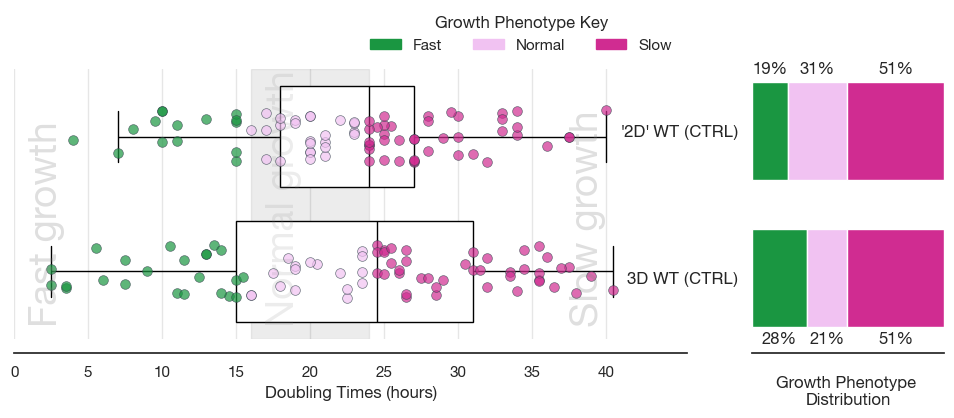

In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- 1. Prepare 2D Reference Data ---
# Note: Assuming 'df' is already exploded/cleaned from previous steps
df_2d_ref = df[(df["Strain_norm"] == "WT") & (df["Compound"] == "CTRL")].copy()
df_2d_ref["Experiment"] = "'2D' WT (CTRL)"

# --- 2. Prepare 3D Data ---
df_3d_clean = df_3d[df_3d['mtb_origin']=='Growth'].copy()

if "Doubling Times" in df_3d_clean.columns:
    df_3d_clean = df_3d_clean.drop_duplicates("ID")
    df_3d_clean = df_3d_clean.explode("Doubling Times", ignore_index=True)
    df_3d_clean["Doubling Times"] = pd.to_numeric(df_3d_clean["Doubling Times"], errors="coerce")
    df_3d_clean = df_3d_clean.dropna(subset=["Doubling Times"])
    df_3d_clean = df_3d_clean[(df_3d_clean["Doubling Times"] > 0) & (~np.isinf(df_3d_clean["Doubling Times"]))]
    df_3d_clean["Experiment"] = "3D WT (CTRL)"
else:
    raise ValueError("df_3d must contain a 'Doubling Times' column")

# Limit 2D data to the max of 3D data for cleaner plotting
df_2d_ref = df_2d_ref[df_2d_ref["Doubling Times"] <= df_3d_clean["Doubling Times"].max()]

# --- SUBSAMPLING LOGIC START ---
# Randomly sample 2D data to match 3D sample size (N)
n_3d = len(df_3d_clean)
n_2d = len(df_2d_ref)

if n_2d > n_3d:
    print(f"Subsampling 2D data (N={n_2d}) to match 3D data (N={n_3d})...")
    df_2d_ref = df_2d_ref.sample(n=n_3d, random_state=42).copy()
else:
    print(f"2D N ({n_2d}) <= 3D N ({n_3d}). No subsampling performed.")
# --- SUBSAMPLING LOGIC END ---

# --- 3. Combine & Bin ---
comp_df = pd.concat([df_2d_ref, df_3d_clean], ignore_index=True)

bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
comp_df["Growth Category"] = pd.cut(comp_df["Doubling Times"], bins=bins, labels=labels, right=False)

# --- 4. Plotting Configuration ---
width_in, height_in = 12, 3.5
fig = plt.figure(figsize=(width_in, height_in))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.15) 

ax_box = plt.subplot(gs[0]) 
ax_bar = plt.subplot(gs[1])

y_order = ["'2D' WT (CTRL)", "3D WT (CTRL)"]
growth_order = ["Fast", "Normal", "Slow"]
growth_colors = {"Fast": '#1a9641', "Normal": '#F1C2F2', "Slow": '#D02C91'}

# ===========================
# LEFT PANEL: BOX & STRIP
# ===========================

box_props = {
    'boxprops': {'facecolor': 'white', 'edgecolor': 'black'},
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'black'},
    'capprops': {'color': 'black'}
}

# A. Base Box Plot
sns.boxplot(
    data=comp_df, x="Doubling Times", y="Experiment",
    order=y_order, 
    width=0.75,           
    linewidth=1.0, 
    fliersize=0,         
    ax=ax_box,
    **box_props
)

# B. Colored Strip Plots
for cat in growth_order:
    cat_data = comp_df[comp_df["Growth Category"] == cat]
    if cat_data.empty: continue
    
    sns.stripplot(
        data=cat_data, x="Doubling Times", y="Experiment",
        order=y_order,
        color=growth_colors[cat],
        jitter=0.2, size=7, linewidth=0.5, edgecolor='#36454F', alpha=0.7, ax=ax_box
    )

# Background Shading
xmax = comp_df["Doubling Times"].max()
for txt, b0, b1, alpha in [("Fast", 0, 16, 0.05), ("Normal", 16, 24, 0.15), ("Slow", 24, xmax+5, 0.05)]:
    color = 'gray' if txt=='Normal' else 'white'        
    ax_box.axvspan(b0, b1, alpha=alpha, color=color)

# --- LABEL LOGIC ---
ymax = len(y_order) - 0.65 
labels_info = [("Fast growth", 1, "left", 0.25), ("Normal growth", 17, "left", 0.15), ("Slow growth", 40, "right", 0.25)]
for txt, xpos, align, alpha in labels_info:
    shaded_region_text_colour = '#36454F' if txt=='Normal' else 'gray'    
    ax_box.text(xpos, ymax, txt, fontsize=28, color=shaded_region_text_colour, alpha=alpha, ha=align, rotation=90)
# -------------------

ax_box.set(xlabel="Doubling Times (hours)", ylabel="", xlim=(0, xmax+5))

# Ticks every 5, excluding 45
ticks = np.arange(0, xmax + 10, 5) 
ticks = [t for t in ticks if t != 45] 

ax_box.xaxis.set_major_locator(ticker.FixedLocator(ticks))
ax_box.grid(True, axis='x', linestyle='-', alpha=0.5)

ax_box.set_yticks([]) 
sns.despine(offset=10, left=True, ax=ax_box)


# ===========================
# RIGHT PANEL: STACKED BARS
# ===========================

# Group Data
g = (comp_df.groupby(["Experiment", "Growth Category"], observed=True)
       .size().unstack("Growth Category", fill_value=0))
g = g.reindex(y_order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

spacing = 0.3      
thickness = 0.2     

y_pos = np.arange(len(y_order)) * spacing

lefts = np.zeros(len(props))
fast_label_x = {}
min_separation = 0.1
handles = [mpatches.Patch(color=growth_colors[k], label=k) for k in growth_order]

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=thickness, 
                       label=gr, color=growth_colors[gr], edgecolor="white")
    
    shift_amount = 0.12
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_center = bar.get_x() + bar.get_width() / 2
            base_y = bar.get_y() + bar.get_height() / 2
            
            if i % 2 == 0:
                y_center = base_y - shift_amount - 0.005
            else:
                y_center = base_y + shift_amount + 0.005

            if gr == "Fast":
                fast_label_x[i] = x_center
            elif gr == "Normal":
                if i in fast_label_x:
                    dist = x_center - fast_label_x[i]
                    if dist < min_separation:
                        x_center = fast_label_x[i] + min_separation - 0.05

            ax_bar.text(x_center, y_center, 
                        f"{v*100:.0f}%", 
                        ha="center", va="center", fontsize=12, fontweight="bold",
                        bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))  

    lefts += vals

ax_bar.legend(handles=handles, title="Growth Phenotype Key", loc="upper center", frameon=False, bbox_to_anchor=(-1.2, 1.25), ncol=3)

ax_bar.set(xlim=(0, 1), xticks=[], ylabel="", xlabel="\nGrowth Phenotype \nDistribution")
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(props.index)
plt.setp(ax_bar.get_yticklabels(), fontweight='bold', fontsize=12, family='Helvetica')

ax_bar.invert_yaxis()
sns.despine(offset=10, left=True, ax=ax_bar)

plt.tight_layout()
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/phenotype_colour_code/3D_doubling_times_random_sample_box_plot_phenotype_colour_code_shifted_percentages.pdf', bbox_inches='tight', dpi=314)
plt.show()

# Stats test of 3D

In [149]:
from scipy.stats import mannwhitneyu, ks_2samp

# 1. Extract the arrays
group_2d = comp_df[comp_df["Experiment"].str.contains("2D")]["Doubling Times"].values
group_3d = comp_df[comp_df["Experiment"].str.contains("3D")]["Doubling Times"].values

# 2. Mann-Whitney U Test (Location/Median)
stat, p_val_mw = mannwhitneyu(group_2d, group_3d, alternative='two-sided')
print(f"Mann-Whitney U Test: p = {p_val_mw:.2e}")

# 3. Kolmogorov-Smirnov Test (Distribution Shape)
stat_ks, p_val_ks = ks_2samp(group_2d, group_3d)
print(f"K-S Test: p = {p_val_ks:.2e}, Statistic = {stat_ks:.4f}")

# 4. Cliff's Delta (Effect Size)
# Function to calculate Cliff's Delta manually (or use 'cliffs_delta' package)
def cliffs_delta(lst1, lst2):
    m, n = len(lst1), len(lst2)
    lst2 = sorted(lst2)
    j = 0
    t = 0
    for x in lst1:
        while j < n and lst2[j] < x:
            j += 1
        t += j * 2 - n + (lst2.count(x)) # handle ties
    return t / (m * n)

d = cliffs_delta(group_2d, group_3d)
print(f"Cliff's Delta: {d:.4f} (Positive = 2D is slower, Negative = 2D is faster)")

Mann-Whitney U Test: p = 6.72e-01
K-S Test: p = 8.52e-02, Statistic = 0.1531
Cliff's Delta: 0.9807 (Positive = 2D is slower, Negative = 2D is faster)
